# DDPM on MNIST

Here, we want to implement and train a simple diffusion model on the MNIST data set, which learns to generate images of handwritten digits.

### Imports, loading the data and fundamental classes


In [1]:
import importlib.util
import sys
import subprocess

# Check if the package is available
if importlib.util.find_spec("torch_lr_finder") is None:
    print("torch_lr_finder not found. Installing...")
    # Install using the current python executable to ensure it hits the right environment
    subprocess.check_call([sys.executable, "-m", "pip",
                          "install", "torch-lr-finder"])
    print("Installation complete.")

In [2]:
from torch_lr_finder import LRFinder
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from tqdm.notebook import tqdm

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from torch.utils.tensorboard import SummaryWriter
import datetime

batch_size = 32


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

/usr/local/lib/python3.12/dist-packages/torch_lr_finder/lr_finder.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


cuda


This class sets the noise schedule beta_t


In [3]:
class NoiseScheduler(nn.Module):
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02):
        super().__init__()
        betas = torch.linspace(beta_start, beta_end, T)
        alphas = 1 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)

        # register as buffers — not parameters, but move with .to(device)
        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alpha_bars', alpha_bars)
        self.T = T

    def _reshape(self, x, t):
        return x.reshape(-1, 1, 1, 1) if isinstance(t, (torch.Tensor, np.ndarray)) else x

    def beta(self, t): return self._reshape(self.betas[t], t)
    def alpha(self, t): return self._reshape(self.alphas[t], t)
    def alpha_bar(self, t): return self._reshape(self.alpha_bars[t], t)

    def add_noise(self, x, t):
        noise = torch.randn_like(x)
        ab = self.alpha_bar(t)
        return torch.sqrt(ab) * x + torch.sqrt(1 - ab) * noise, noise


scheduler = NoiseScheduler(T=1000)

NoisyMNIST is the data set on which the MNIST is trained: noisy image -> noise pattern


In [4]:
# cell written by Claude
class NoisyMNIST(torch.utils.data.Dataset):
    def __init__(self, dataset, scheduler):
        self.dataset = dataset
        self.scheduler = scheduler

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # the device on which the scheduler lies
        scheduler_device = self.scheduler.betas.device
        # the second entry (the number) is being ignored
        x, _ = self.dataset[idx]
        t = torch.randint(0, self.scheduler.T, (1,))
        x_noisy, noise = self.scheduler.add_noise(x.unsqueeze(0).to(scheduler_device), t.to(
            scheduler_device))  # TODO: maybe i rather send the scheduler to the device of the dataset
        return x_noisy.squeeze(0), noise.squeeze(0)

In [5]:


def load_mnist(transform=None):
    if transform is None:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
    train_set = datasets.MNIST(
        root='./data', train=True,  download=True, transform=transform)
    test_set = datasets.MNIST(
        root='./data', train=False, download=True, transform=transform)
    return train_set, test_set


def get_noisy_loaders(train_set, test_set, scheduler, batch_size=32):
    train_zeros = NoisyMNIST(train_set, scheduler)
    test_zeros = NoisyMNIST(test_set, scheduler)
    train_loader = DataLoader(train_zeros, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_zeros,  batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

In [6]:
train_set, test_set = load_mnist()
train_loader, test_loader = get_noisy_loaders(
    train_set, test_set, scheduler, batch_size)

In [7]:
# plt.imshow(train_set[0][0].squeeze(), cmap="gray")

In [8]:
from typing import List


class UNet(nn.Module):

    def __init__(self, channels: List[int] = [32, 64, 128], convs_per_level=2,
                 kernel_size=3, pool_size=2, padding=1):
        super().__init__()

        full_channels = [1] + channels + channels[-2::-1]
        # [1, 8, 16, 32, 16, 8]

        self.mid = len(full_channels) // 2

        self.encoder_convs = nn.ModuleList([
            # one ModuleList per resolution level (so this is a Module List of BLocks of N convs)
            # first conv changes channels: full_channels[i] -> full_channels[i+1]
            # remaining convs keep channels constant: full_channels[i+1] -> full_channels[i+1]
            # example with channels=[8,16,32], convs_per_level=2:
            #   level 0 (28x28): Conv(1->8),  Conv(8->8)
            #   level 1 (14x14): Conv(8->16), Conv(16->16)
            #   level 2 (7x7):   Conv(16->32), Conv(32->32)  <- bottleneck, no pool after
            nn.ModuleList([
                nn.Conv2d(full_channels[i] if j == 0 else full_channels[i+1],
                          full_channels[i+1], kernel_size, padding=padding)
                for j in range(convs_per_level)
            ])
            for i in range(self.mid)
        ])

        self.decoder_convs = nn.ModuleList([
            # one ModuleList per resolution level
            # first conv takes concatenated skip+upsampled: (full_channels[mid+i] + full_channels[mid-i-1]) -> full_channels[mid+i+1]
            # remaining convs keep channels constant: full_channels[mid+i+1] -> full_channels[mid+i+1]
            # example with channels=[8,16,32], convs_per_level=2:
            #   level 0 (7x7->14x14):  Conv(32+16->16), Conv(16->16)
            #   level 1 (14x14->28x28): Conv(16+8->8),  Conv(8->8)
            # then output_conv: Conv(8->1, kernel=1)
            nn.ModuleList([
                nn.Conv2d(
                    (full_channels[self.mid + i] + full_channels[self.mid - i - 1]) if j == 0
                    else full_channels[self.mid + i + 1],
                    full_channels[self.mid + i + 1],
                    kernel_size, padding=padding
                )
                for j in range(convs_per_level)
            ])
            for i in range(len(full_channels) - self.mid - 1)
        ])

        # final output conv: 8 -> 1, no activation
        self.output_conv = nn.Conv2d(full_channels[-1], 1, kernel_size=1)

        self.pool = nn.MaxPool2d(pool_size)
        self.upsample = nn.Upsample(scale_factor=pool_size)
        self.activation_fn = F.relu

    def forward(self, x):
        skips = []
        last_encoder = len(self.encoder_convs) - 1
        for i, conv_block in enumerate(self.encoder_convs):
            for conv in conv_block:
                x = self.activation_fn(conv(x))
            if i < last_encoder:
                skips.append(x)
                x = self.pool(x)

        for i, conv_block in enumerate(self.decoder_convs):
            x = self.upsample(x)
            x = torch.cat([x, skips.pop()], dim=1)
            for conv in conv_block:
                x = self.activation_fn(conv(x))

        return self.output_conv(x)  # no activation on final layer

### training the model


In [9]:
def find_lr(model, train_loader, start_lr=1e-7, end_lr=1, num_iter=100, plot=True):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=start_lr)
    lr_finder = LRFinder(model, optimizer, F.mse_loss)
    lr_finder.range_test(train_loader, end_lr=end_lr, num_iter=num_iter)
    ax, suggest_lr = lr_finder.plot(suggest_lr=True)
    lr_finder.reset()

    return suggest_lr

we add gradient clipping here also


In [10]:
def train(model, train_loader, test_loader, epochs=100, lr=1e-2, weight_decay = 1e-4, plot_loss=True,
          early_stopping_patience=10, save_path='model.pkl', writer=None):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr,weight_decay=weight_decay)
    scaler = torch.amp.GradScaler('cuda')
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5, min_lr=1e-6)

    loss_fn = nn.MSELoss()
    train_losses, test_losses = [], []

    best_test_loss = float('inf')
    patience_counter = 0

    for epoch in tqdm(range(epochs), desc='Epochs'):
        model.train()
        epoch_train_loss = 0
        for x_noisy, noise in tqdm(train_loader, leave=False, desc='train'):
            x_noisy, noise = x_noisy.to(device), noise.to(device)
            with torch.amp.autocast('cuda'):
                noise_pred = model(x_noisy)
                loss = loss_fn(noise_pred, noise)
            epoch_train_loss += loss.item()
            optimizer.zero_grad()
            scaler.scale(loss).backward()

            # gradient clipping
            scaler.unscale_(optimizer)
            # Clip the gradients (max_norm=1.0 is a common default)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimizer)
            scaler.update()

        train_losses.append(epoch_train_loss / len(train_loader))

        model.eval()
        epoch_test_loss = 0
        with torch.no_grad():
            for x_noisy, noise in tqdm(test_loader, leave=False, desc='test'):
                x_noisy, noise = x_noisy.to(device), noise.to(device)
                with torch.amp.autocast('cuda'):
                    noise_pred = model(x_noisy)
                    epoch_test_loss += loss_fn(noise_pred, noise).item()
            test_loss = epoch_test_loss / len(test_loader)
            lr_scheduler.step(test_loss)
        test_losses.append(test_loss)

        print(
            f"Epoch {epoch} | train loss: {train_losses[-1]:.4f} | test loss: {test_losses[-1]:.4f}")

        if writer:
            writer.add_scalar('Loss/train', epoch_train_loss, epoch)
            writer.add_scalar('Loss/test', test_loss, epoch)
            # You can even track learning rate
            writer.add_scalar(
                'Params/LR', optimizer.param_groups[0]['lr'], epoch)

        # early stopping
        if test_losses[-1] < best_test_loss:
            best_test_loss = test_losses[-1]
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"Early stopping at epoch {epoch}")
                break

    # restore best model
    model.load_state_dict(torch.load(save_path))

    if plot_loss:
        plt.figure(figsize=(8, 4))
        plt.plot(train_losses, label='Train')
        plt.plot(test_losses, label='Test')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss curve')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return train_losses, test_losses

### Generating an image


In [11]:
example_image = train_set[0][0].squeeze()


def noisy_image(n=1):
    """generates a batch of n noisy images. Output shape: (nx28x28)"""
    return torch.randn((n, 1, *example_image.shape))


# plt.imshow(noisy_image().squeeze(), cmap="gray")
# plt.show()

In [12]:
def plot_image(image):
    plt.imshow(image.cpu().detach().squeeze(), cmap="gray")
    plt.colorbar()

In [13]:
import math


def generate_image(unet, scheduler, stochasticity=1.0, n_images=1, return_intermediates=False, plot=True, ncol=4):
    intermediates = []
    unet.eval()

    x = noisy_image(n_images).to(device)
    if return_intermediates:
        intermediates.append(x.cpu())

    with torch.no_grad():
        for t in range(scheduler.T-1, 0, -1):
            z = noisy_image(n_images).to(
                device) if t > 1 else torch.zeros_like(x)
            alpha = scheduler.alpha(t)
            alpha_bar = scheduler.alpha_bar(t)
            # sigma_t is here for this simple case set to sqrt(beta), like in the original ho et al paper
            sigma_t = stochasticity*torch.sqrt(scheduler.beta(t))

            noise_pred = unet(x)
            x = 1/torch.sqrt(alpha) * (x - (1-alpha) /
                                       torch.sqrt(1-alpha_bar)*noise_pred) + sigma_t*z

            # print(t, alpha_bar.item(), (1-alpha_bar).item())

            if return_intermediates:
                intermediates.append(x.cpu())

        if plot:
            # Move to CPU and prepare for plotting
            imgs = x.detach().cpu()
            # Handle different image shapes (C, H, W) -> (H, W, C)
            if imgs.shape[1] in [1, 3]:
                imgs = imgs.permute(0, 2, 3, 1)

            # Squeeze grayscale if necessary
            if imgs.shape[-1] == 1:
                imgs = imgs.squeeze(-1)

            nrow = math.ceil(n_images / ncol)
            fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 3, nrow * 3))
            axes = axes.flatten() if n_images > 1 else [axes]

            for i in range(n_images):
                ax = axes[i]
                # Clip/Normalize if your images are in range [-1, 1] or [0, 1]
                display_img = imgs[i]
                if display_img.min() < 0:  # typical for diffusion
                    display_img = (display_img + 1) / 2

                ax.imshow(display_img.clamp(0, 1),
                          cmap='gray' if imgs.ndim == 3 else None)
                ax.axis('off')

            # Hide empty subplots
            for j in range(n_images, len(axes)):
                axes[j].axis('off')

            plt.tight_layout()
            plt.show()

    if return_intermediates:
        return x, intermediates

    return x

In [14]:
def plot_stochasticities(model, scheduler, stochasticities=[0, 0.33, 0.67, 1.0], ncols=2):
    nrows = len(stochasticities) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2, nrows*2))

    for ax, s in zip(axes.flat, stochasticities):
        image = generate_image(model, scheduler, stochasticity=s, n_images=1)
        ax.imshow(image.cpu().detach().squeeze(), cmap='gray')
        ax.set_title(f's={s}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

### Intermediary conclusion

Models that work kind of well so far:


In [15]:
def load_unet(state_dict_path, channels, convs_per_level):
    unet = UNet(channels, convs_per_level=convs_per_level)
    unet.load_state_dict(torch.load(state_dict_path, map_location=device))
    unet.to(device)
    unet.eval()
    return unet

we create a test model function to further speed up our workflow


In [16]:
def test_model(model, train_loader, test_loader, epochs=5, T=1000, weight_decay = 1e-4, save_path='model.pkl', n_images=8, ncol=4, return_losses=True, plot=False):
    # find learning rate
    suggested_lr = find_lr(model, train_loader)
    lr = suggested_lr * 0.5  # conservative estimate for better stability
    print(f"Recommended LR: {suggested_lr:.2e} -> Used LR: {lr:.2e}")

    train_losses, test_losses = train(
        model, train_loader, test_loader,
        epochs=epochs, lr=lr, weight_decay = weight_decay,
        early_stopping_patience=10,
        save_path=save_path
    )

    # 4. Generierung & Plot
    scheduler = NoiseScheduler(T=T)
    images = generate_image(model, scheduler, stochasticity=1,
                            n_images=n_images, ncol=ncol, plot=plot)

    if return_losses:
        return images, train_losses, test_losses

    return images


model = UNet(channels=[64, 128, 256], convs_per_level=2).to(device)

In [17]:
def channel_list(channel0):
    return [channel0, channel0*2, channel0*4]


def model_name(channel0, convs_per_level):
    return f'C0_{channel0}_convs_{convs_per_level}'


def path_name(channel0, convs_per_level,add_desc=""):
    modelname = model_name(channel0, convs_per_level)
    return f"base_{modelname}{add_desc}.pkl"

In [18]:
def plot_model_comparison(images_list, model_names, ncol=None):
    n_models = len(images_list)

    for m_idx in range(n_models):
        imgs = images_list[m_idx].detach().cpu()
        name = model_names[m_idx]
        n_images = imgs.shape[0]

        # If ncol is None, put all images of the model in one row
        current_ncol = ncol if ncol is not None else n_images
        nrow = math.ceil(n_images / current_ncol)

        # Handle shape (B, C, H, W) -> (B, H, W, C)
        if imgs.shape[1] in [1, 3]:
            imgs = imgs.permute(0, 2, 3, 1)
        if imgs.shape[-1] == 1:
            imgs = imgs.squeeze(-1)

        fig, axes = plt.subplots(nrow, current_ncol,
                                 figsize=(current_ncol * 2.5, nrow * 2.5))

        # Add model name as main title for this section
        fig.suptitle(f"Model: {name}", fontsize=16, fontweight='bold', y=1.02)

        # Flatten axes array for easy indexing
        if n_images == 1 and nrow == 1 and current_ncol == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        for i in range(n_images):
            ax = axes[i]
            display_img = imgs[i]

            # Normalize from [-1, 1] to [0, 1] if necessary
            if display_img.min() < 0:
                display_img = (display_img + 1) / 2

            ax.imshow(display_img.clamp(0, 1),
                      cmap='gray' if imgs.ndim == 3 else None)
            ax.axis('off')

        # Hide unused subplot slots
        for j in range(n_images, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 1.48E-03


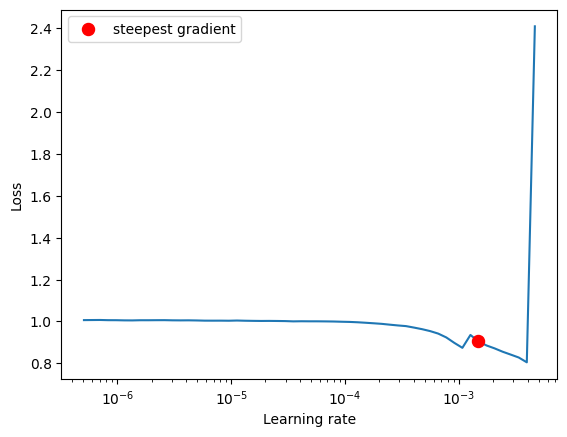

Recommended LR: 1.48e-03 -> Used LR: 7.42e-04


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

train:   0%|          | 0/1875 [00:00<?, ?it/s]

test:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.0599 | test loss: 0.0367


...

test:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 3 | train loss: 0.0317 | test loss: 0.0305


train:   0%|          | 0/1875 [00:00<?, ?it/s]

test:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 4 | train loss: 0.0311 | test loss: 0.0284


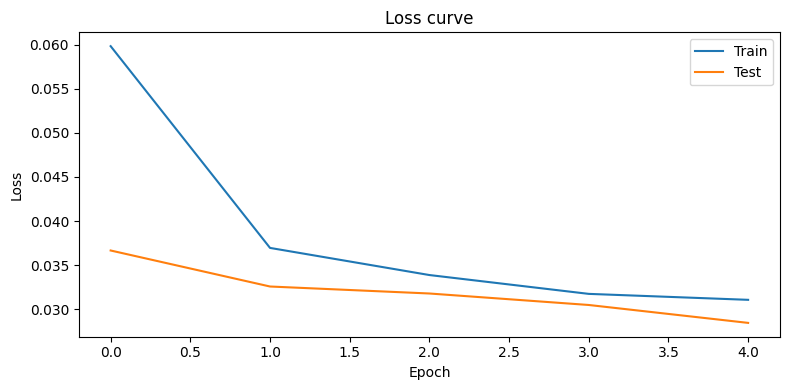

  0%|          | 0/100 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 1.26E-03


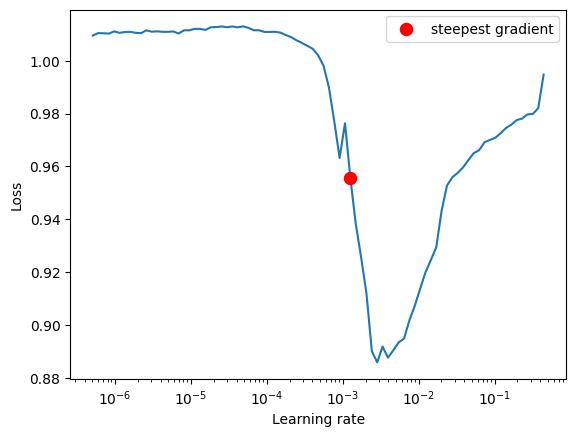

Recommended LR: 1.26e-03 -> Used LR: 6.31e-04


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

train:   0%|          | 0/1875 [00:00<?, ?it/s]

test:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.0665 | test loss: 0.0405


...

test:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 3 | train loss: 0.0313 | test loss: 0.0341


train:   0%|          | 0/1875 [00:00<?, ?it/s]

test:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 4 | train loss: 0.0301 | test loss: 0.0289


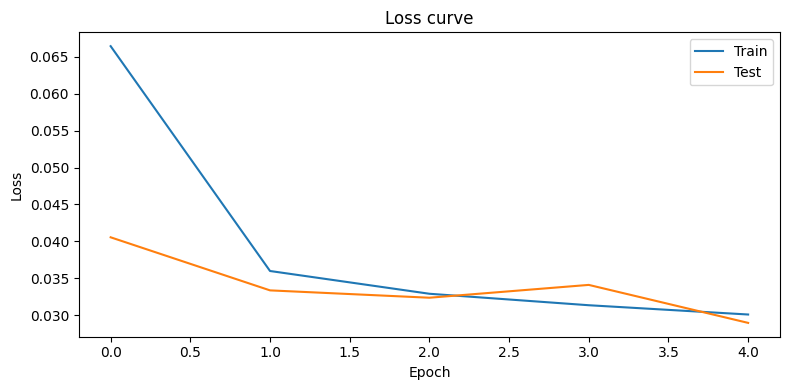

  0%|          | 0/100 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 6.58E-04


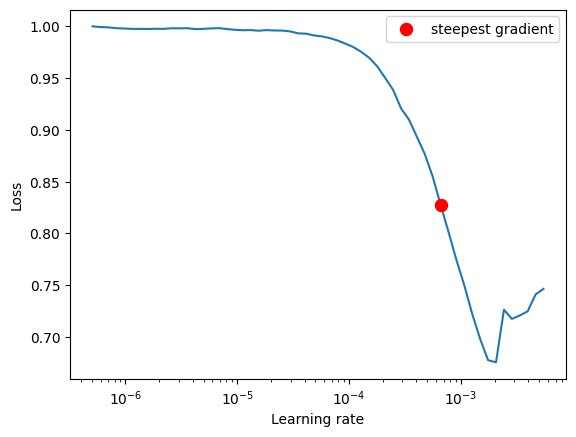

Recommended LR: 6.58e-04 -> Used LR: 3.29e-04


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

train:   0%|          | 0/1875 [00:00<?, ?it/s]

test:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.0562 | test loss: 0.0348


...

test:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 3 | train loss: 0.0293 | test loss: 0.0273


train:   0%|          | 0/1875 [00:00<?, ?it/s]

test:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 4 | train loss: 0.0283 | test loss: 0.0269


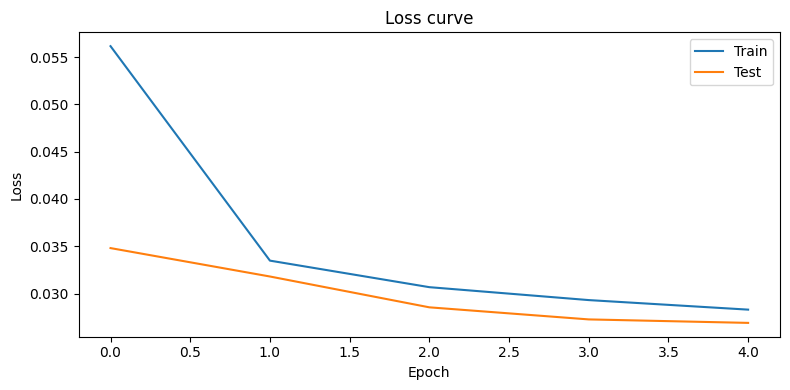

  0%|          | 0/100 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 9.11E-04


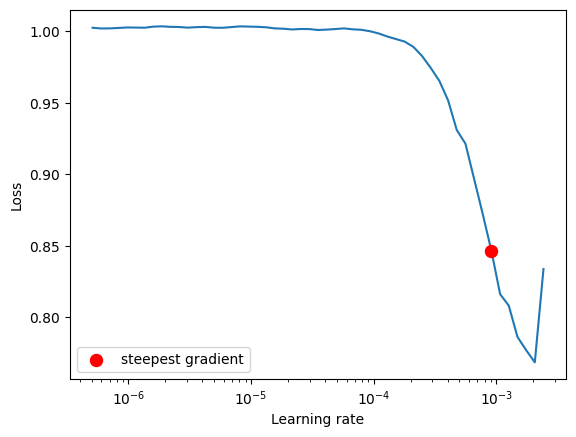

Recommended LR: 9.11e-04 -> Used LR: 4.56e-04


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

train:   0%|          | 0/1875 [00:00<?, ?it/s]

test:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.0564 | test loss: 0.0363


...

train:   0%|          | 0/1875 [00:00<?, ?it/s]

test:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 2 | train loss: 0.0305 | test loss: 0.0279


train:   0%|          | 0/1875 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
model_names, image_list, train_losses, test_losses = [], [], [], []

channel0s = [64, 128, 64]
convs_per_level = [2, 2, 3]

for channel0, cpl in zip(channel0s, convs_per_level):
    unet = UNet(channel_list(channel0), cpl).to(device)
    imgs, trainlosses, testlosses = test_model(
        unet, train_loader, test_loader, save_path=path_name(channel0, cpl), n_images=4)

    model_names.append(model_name(channel0, cpl))
    image_list.append(imgs)
    train_losses.append(trainlosses)
    test_losses.append(testlosses)

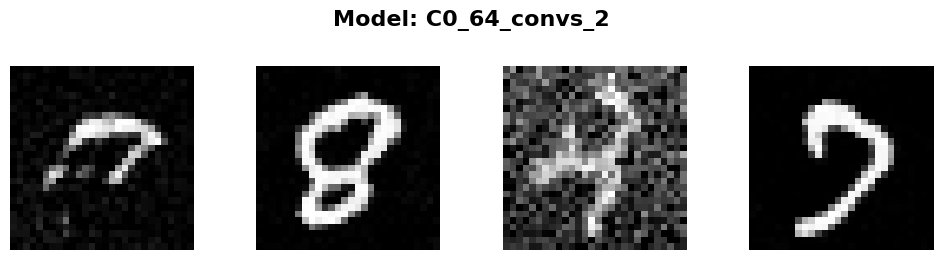

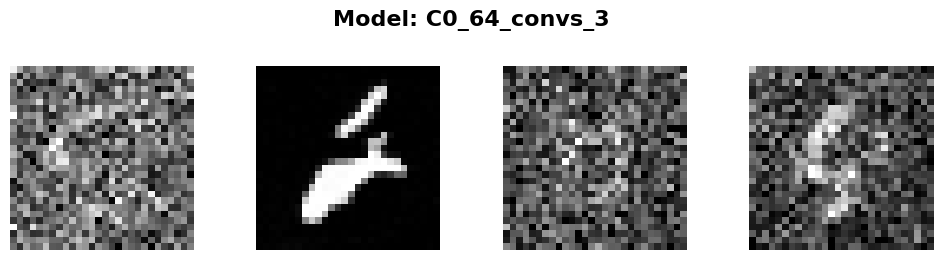

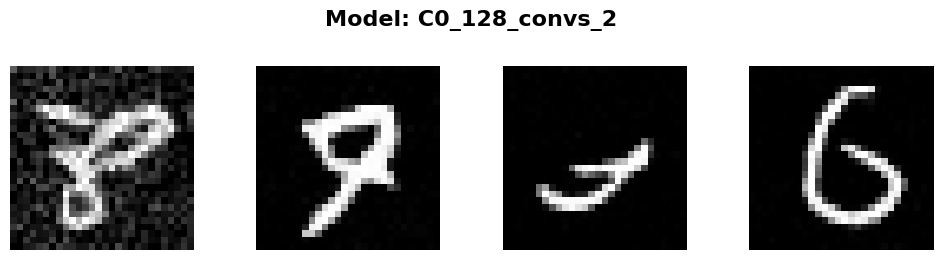

In [ ]:
plot_model_comparison(image_list, model_names)

  0%|          | 0/100 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 5.59E-04


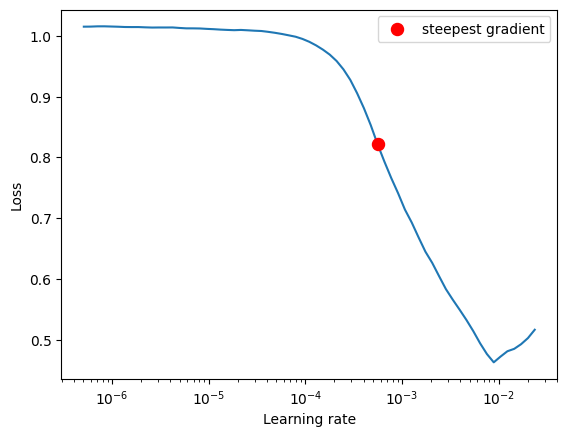

Recommended LR: 5.59e-04 -> Used LR: 2.80e-04


Epochs:   0%|          | 0/200 [00:00<?, ?it/s]

train:   0%|          | 0/1875 [00:00<?, ?it/s]

test:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.0617 | test loss: 0.0380


...

train:   0%|          | 0/1875 [00:00<?, ?it/s]

test:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 9 | train loss: 0.0305 | test loss: 0.0327


train:   0%|          | 0/1875 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [21]:
channel0 = 128
cpl = 2
unet = UNet(channel_list(channel0), cpl).to(device)
imgs, trainlosses, testlosses = test_model(unet, train_loader, test_loader,
                                           epochs=200,
                                           save_path=path_name(channel0, cpl), n_images=8, plot=True)

weight decay hurts here still, so I stopped it early. We will now train the model with lower weight decay again (1e-6), bc i did get a feeling (although no numbers) that we see slight overfitting with zero weight decay, but that needs to be investigated in detail still

  0%|          | 0/100 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 5.59E-04


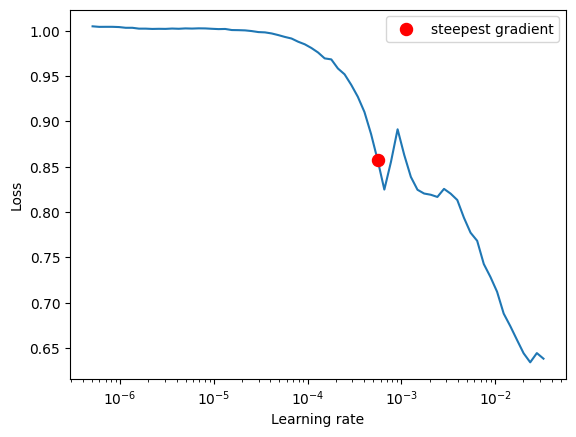

Recommended LR: 5.59e-04 -> Used LR: 2.80e-04


Epochs:   0%|          | 0/200 [00:00<?, ?it/s]

train:   0%|          | 0/1875 [00:00<?, ?it/s]

test:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.0606 | test loss: 0.0420


...

Epoch 7 | train loss: 0.0271 | test loss: 0.0263


train:   0%|          | 0/1875 [00:00<?, ?it/s]

test:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 8 | train loss: 0.0269 | test loss: 0.0278


train:   0%|          | 0/1875 [00:00<?, ?it/s]

In [ ]:
channel0 = 128
cpl = 2
unet = UNet(channel_list(channel0), cpl).to(device)
imgs, trainlosses, testlosses = test_model(unet, train_loader, test_loader,
                                           epochs=200, weight_decay=1e-6,
                                           save_path=path_name(channel0, cpl,add_desc="wd_1e-6_long"), n_images=8, plot=True)

Next Steps:

time embedding

use cosine based variance schedule (nochol & dhariwal)

conditioning on input numbers
